24RB1074　半田悠人

## 課題：決定木の実装

In [8]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier as SklearnDT

In [9]:
class Node:
    """決定木の1ノード．内部ノードと葉ノードを単一クラスで表現する．

    - 内部ノード：``feature_id`` / ``threshold`` / ``left`` / ``right`` を埋める．
    - 葉ノード：``label`` / ``proba`` を埋める（``left``，``right`` は ``None`` のまま）．
    """

    def __init__(self) -> None:
        self.feature_id: int | None = None
        self.threshold: float | None = None
        self.left: "Node | None" = None
        self.right: "Node | None" = None
        self.label: int | None = None
        self.proba: np.ndarray | None = None

    def is_leaf(self) -> bool:
        return self.left is None and self.right is None


In [10]:
class DecisionTreeClassifier:
    """``fit`` / ``predict`` を備えた決定木分類器．

    すべての処理（不純度計算・最良分割・再帰的な木の構築・予測）を
    このクラスのメソッドとして実装する．
    """

    def __init__(
        self,
        max_depth: int = 5,
        min_samples: int = 2,
        criterion: str = "gini",
    ) -> None:
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.criterion = criterion
        self.root: Node | None = None

    # --------------------------------------------------------
    # 不純度
    # --------------------------------------------------------
    def _impurity(self, y: np.ndarray) -> float:
        """``self.criterion`` に従って不純度を返す（Gini または Entropy）．"""
        if self.criterion == "gini":
            return self._gini(y)
        if self.criterion == "entropy":
            return self._entropy(y)
        
        raise ValueError(f"unknown criterion: {self.criterion!r}")

    @staticmethod
    def _gini(y: np.ndarray) -> float:
        """Gini 不純度 :math:`1 - \\sum_c p_c^2` を返す．"""
        # TODO: ラベル配列 y から各クラスの割合 p_c を求め，Gini 不純度を計算する
        if len(y) == 0:
            return 0.0
        p_c = np.bincount(y) / len(y)
        return 1.0 - np.sum(p_c**2)
    
        raise NotImplementedError

    @staticmethod
    def _entropy(y: np.ndarray) -> float:
        """エントロピー :math:`-\\sum_c p_c \\log_2 p_c` を返す．"""
        # TODO: ラベル配列 y から各クラスの割合 p_c を求め，エントロピーを計算する
        if len(y) == 0:
            return 0.0
        p_c = np.bincount(y) / len(y)
        p_c = p_c[p_c > 0]

        return -np.sum(p_c * np.log2(p_c))
    
        raise NotImplementedError

    # --------------------------------------------------------
    # 最良分割
    # --------------------------------------------------------
    def _best_split(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ) -> tuple[int | None, float | None, float]:
        """情報利得が最大になる ``(feature_id, threshold, gain)`` を返す．

        分割が見つからない（または利得が 0 以下）の場合は ``(None, None, 0.0)``．
        """
        # TODO:
        delta = 0.0
        delta_max = 0.0
        j_max = None
        s_max = None

        # 1. 親ノードの不純度 ell(S) を self._impurity(y) で計算
        ell = self._impurity(y)

        # 2. すべての特徴 j について：
        for j in range(X.shape[1]):
            
            # X[:, j] のユニーク値の中間点を閾値候補にする
            sorted_x = np.sort(np.unique(X[:, j]))
            for i in range(len(sorted_x) - 1):
                s = (sorted_x[i] + sorted_x[i + 1]) / 2

                # 各閾値 s で y を S^1 (x_j <= s), S^2 (x_j > s) に分割
                left = y[X[:, j] <= s]
                right = y[X[:, j] > s]
                if len(left) == 0 or len(right) == 0:
                    continue

                # 情報利得 ell(S) - |S^1|/|S| ell(S^1) - |S^2|/|S| ell(S^2) を計算
                delta = ell - len(left) / len(y) * self._impurity(left) - len(right) / len(y) * self._impurity(right)
                if delta > delta_max:
                    delta_max = delta
                    j_max = j
                    s_max = s
        
        # 3. 情報利得が最大の (j, s, gain) を返す
        if delta_max > 0:   
            return j_max, s_max, delta_max
        else:            
            return None, None, 0.0
        
        raise NotImplementedError

    # --------------------------------------------------------
    # 木の構築（再帰）
    # --------------------------------------------------------
    def _build_tree(self, X: np.ndarray, y: np.ndarray, depth: int = 0) -> Node:
        """データ ``(X, y)`` から ``Node`` を再帰的に構築する．"""
        node = Node()

        # TODO: 葉にする停止条件を判定し，葉なら label / proba を埋めて return
        if depth >= self.max_depth or len(y) < self.min_samples or len(np.unique(y)) == 1:
            node.label = np.bincount(y).argmax()
            node.proba = np.bincount(y) / len(y)
            return node

        # TODO: self._best_split(X, y) を呼ぶ．分割が得られなければ葉にして return
        feature_id, threshold, gain = self._best_split(X, y)

        if feature_id is None and threshold is None:
            node.label = np.bincount(y).argmax()
            node.proba = np.bincount(y) / len(y)
            return node

        # TODO: 分割が得られたら子ノードを再帰的に構築：
        node.feature_id = feature_id
        node.threshold = threshold

        left_x = X[X[:, feature_id] <= threshold]
        left_y = y[X[:, feature_id] <= threshold]

        right_x = X[X[:, feature_id] > threshold]
        right_y = y[X[:, feature_id] > threshold]

        node.left = self._build_tree(left_x, left_y, depth + 1)
        node.right = self._build_tree(right_x, right_y, depth + 1)

        return node
    
        raise NotImplementedError

    # --------------------------------------------------------
    # 予測
    # --------------------------------------------------------
    def _predict_one(self, x: np.ndarray) -> int:
        """単一サンプル ``x`` の予測ラベルを返す（``self.root`` から辿る）．"""
        # TODO: self.root から始め，葉に到達するまで
        #   x[node.feature_id] <= node.threshold で left/right に降りる
        node = self.root
        while not node.is_leaf():
            if x[node.feature_id] <= node.threshold:
                node = node.left
            else:
                node = node.right
        
         # TODO: 葉に到達したら node.label を返す
        return node.label

        raise NotImplementedError

    # --------------------------------------------------------
    # 公開 API（sklearn 互換）
    # --------------------------------------------------------
    def fit(self, X: np.ndarray, y: np.ndarray) -> "DecisionTreeClassifier":
        """訓練データから決定木を学習する．"""
        self.root = self._build_tree(X, y, depth=0)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """``X`` の各行に対する予測ラベルの配列を返す．"""
        assert self.root is not None, "fit() を呼んでから predict() してください"
        return np.array([self._predict_one(x) for x in X])


### 散布図と決定境界

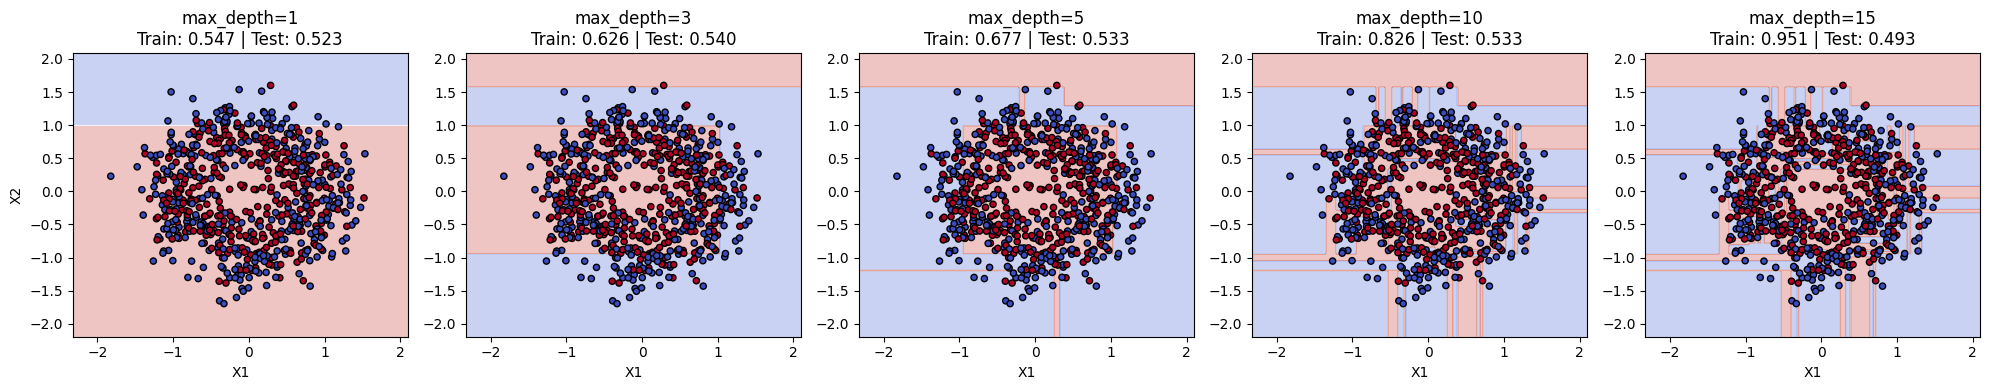

In [11]:
# データの準備
X, y = make_circles(n_samples=1000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


depths_to_plot = [1, 3, 5, 10, 15]
plt.figure(figsize=(20, 4))

# プロット用のグリッドを作成（画面全体の座標点）
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                        np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

for i, depth in enumerate(depths_to_plot):
    # 自作モデルで学習（Gini基準）
    clf_visual = DecisionTreeClassifier(max_depth=depth, criterion="gini")
    clf_visual.fit(X_train, y_train)
    
    # 精度計算
    train_acc = accuracy_score(y_train, clf_visual.predict(X_train))
    test_acc = accuracy_score(y_test, clf_visual.predict(X_test))
    
    # グリッド全体の予測（境界線を描くため）
    Z = clf_visual.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # プロット
    plt.subplot(1, len(depths_to_plot), i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    # 学習データを散布図で重ねる
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k', cmap=plt.cm.coolwarm)
    
    plt.title(f"max_depth={depth}\nTrain: {train_acc:.3f} | Test: {test_acc:.3f}")
    plt.xlabel("X1")
    if i == 0:
        plt.ylabel("X2")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()

## 発展課題

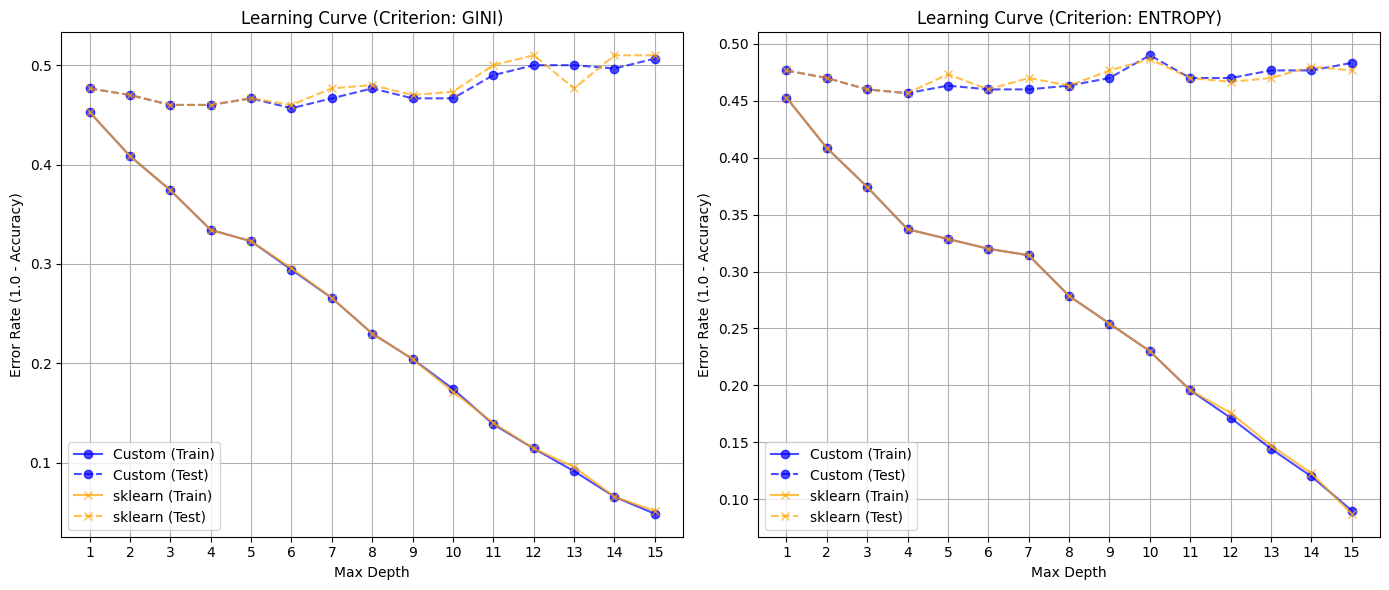

In [12]:
max_depths = range(1, 16)
criteria = ["gini", "entropy"]

plt.figure(figsize=(14, 6))

for i, criterion in enumerate(criteria):
    custom_train_err, custom_test_err = [], []
    sk_train_err, sk_test_err = [], []

    for depth in max_depths:
        # --- 自作モデル ---
        clf_custom = DecisionTreeClassifier(max_depth=depth, criterion=criterion)
        clf_custom.fit(X_train, y_train)
        custom_train_err.append(1.0 - accuracy_score(y_train, clf_custom.predict(X_train)))
        custom_test_err.append(1.0 - accuracy_score(y_test, clf_custom.predict(X_test)))

        # --- sklearnモデル ---
        clf_sk = SklearnDT(max_depth=depth, criterion=criterion, random_state=42)
        clf_sk.fit(X_train, y_train)
        sk_train_err.append(1.0 - accuracy_score(y_train, clf_sk.predict(X_train)))
        sk_test_err.append(1.0 - accuracy_score(y_test, clf_sk.predict(X_test)))

    # --- サブプロット ---
    plt.subplot(1, 2, i + 1)
    plt.plot(max_depths, custom_train_err, label="Custom (Train)", marker='o', color='blue', alpha=0.7)
    plt.plot(max_depths, custom_test_err, label="Custom (Test)", marker='o', linestyle='--', color='blue', alpha=0.7)
    plt.plot(max_depths, sk_train_err, label="sklearn (Train)", marker='x', color='orange', alpha=0.7)
    plt.plot(max_depths, sk_test_err, label="sklearn (Test)", marker='x', linestyle='--', color='orange', alpha=0.7)

    plt.title(f"Learning Curve (Criterion: {criterion.upper()})")
    plt.xlabel("Max Depth")
    plt.ylabel("Error Rate (1.0 - Accuracy)")
    plt.xticks(max_depths)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()  

## 観察と考察

### 1. 決定境界の変化
* **浅い決定木（max_depth = 1〜3）:** 表現力が不足し、アンダーフィッティングが見て取れる。
* **深い決定木（max_depth = 10〜15）:** クラス境界が極めて複雑でジグザグな形状に変化しており、過学習となっている。
* **考察:** 決定木は空間を軸に直交する直線で再帰的に切り分けるアルゴリズムであるため、停止条件を設けないと、訓練データに対して正解率100%を達成するまで無限に細かく空間を切り刻んでしまい、バリアンスが極めて高くなってしまう。そのため、深さや領域内の要素数など、適切な停止条件を設けることが不可欠である。

### 2. 学習曲線
* **自作モデルと既存ライブラリ:** 自作した決定木モデルと `scikit-learn` のモデルによる訓練誤差・テスト誤差の推移が極めて高い精度で一致した。これにより、不純度の計算から最良分割の探索、再帰的なノード生成に至るまでの内部ロジックが正しく実装できているといえる。
* **過学習の発生:** 木の深さ（`max_depth`）が1から4付近までは、層が深くなるにつれて訓練誤差・テスト誤差ともに低下し、順調にデータの法則を学習している。しかし、深さが5を超えたあたりから、訓練誤差は0に向けて下がり続ける一方で、テスト誤差は底を打って上昇に転じている。これは、モデルが訓練データのノイズまで学習に取り込み、過学習が発生したためである。本データセットにおいては、深さ3〜4付近が未学習と過学習のトレードオフが最も取れた最適なハイパーパラメータであると言える。
* **Gini係数とエントロピーの比較:** どちらも過学習に陥るタイミングはほぼ同じであった。エントロピーは対数計算を伴うため、二乗和を用いるGini基準よりも計算コストが高い。このため、近い結果を返すなら、計算効率に優れるGini係数がデフォルトとして採用されるのは合理的である。

## AI利用について
本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習

    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `numpy.bincount`, `numpy.unique`

* グラフのプロット（Copilotの活用）

    * 元の2次元空間に非線形な決定境界を描画するためのコード作成にCopilotを活用した。
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。
